In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")


1.  **Prompt:** You, the user, initiate the process by providing a clear and specific request or problem description to the AI.
2.  **Generate Code:** The AI processes your prompt and generates code or a solution based on its understanding and capabilities.
3.  **Run Code:** You then execute the generated code in your environment (e.g., a Colab notebook).
4.  **Read Errors/Results:** After execution, you carefully examine the output, looking for any errors, unexpected results, or areas where the output doesn't quite meet your expectations.
5.  **Fix/Improve:** Based on your observations from the previous step, you either debug the code yourself or provide refined instructions and feedback to the AI to help it correct or enhance its previous output.
6.  **Repeat:** This loop continues, iterating through prompting, generating, running, evaluating, and refining, until the desired outcome is achieved. This iterative feedback mechanism is crucial for effectively collaborating with an AI assistant to arrive at a satisfactory solution.

In [43]:
df= pd.read_csv('/content/diabetes.csv')

In [44]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [45]:
df.tail()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1
767,1,93,70,31,0,30.4,0.315,23,0


In [46]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
None


In [47]:
display(df.describe())

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [48]:
df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [49]:
df.shape

(768, 9)

In [50]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

## Data Cleaning

### Identify and Report Zero Values

Certain columns in this dataset (like `Glucose`, `BloodPressure`, `SkinThickness`, `Insulin`, and `BMI`) having a value of `0` are biologically implausible and should be treated as missing data. Let's count these zero values.

In [51]:
columns_with_zeros = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

for col in columns_with_zeros:
    zero_count = (df[col] == 0).sum()
    print(f'Number of zero values in {col}: {zero_count}')

Number of zero values in Glucose: 5
Number of zero values in BloodPressure: 35
Number of zero values in SkinThickness: 227
Number of zero values in Insulin: 374
Number of zero values in BMI: 11


### Replace Zero Values with NaN and Create `clean_df`



In [52]:
# Create a copy to avoid modifying the original DataFrame directly
clean_df = df.copy()

# Replace 0s with NaN in the specified columns
for col in columns_with_zeros:
    clean_df[col] = clean_df[col].replace(0, np.nan)

# Drop rows where 'Glucose' is NaN
clean_df = clean_df.dropna(subset=['Glucose'])

### Verify Data Cleaning



In [53]:
print('--- Info for clean_df ---')
clean_df.info()
print('\n--- Describe for clean_df ---')
display(clean_df.describe())

--- Info for clean_df ---
<class 'pandas.core.frame.DataFrame'>
Index: 763 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               763 non-null    int64  
 1   Glucose                   763 non-null    float64
 2   BloodPressure             728 non-null    float64
 3   SkinThickness             536 non-null    float64
 4   Insulin                   393 non-null    float64
 5   BMI                       752 non-null    float64
 6   DiabetesPedigreeFunction  763 non-null    float64
 7   Age                       763 non-null    int64  
 8   Outcome                   763 non-null    int64  
dtypes: float64(6), int64(3)
memory usage: 59.6 KB

--- Describe for clean_df ---


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,763.000000,763.000000,728.000000,536.000000,393.000000,752.000000,763.000000,763.000000,763.000000
mean,3.851900,121.686763,72.438187,29.149254,155.885496,32.454654,0.472477,33.271298,0.348624
std,3.374729,30.535641,12.386109,10.494686,118.738199,6.928926,0.331963,11.772161,0.476847
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,64.000000,22.000000,77.000000,27.500000,0.243500,24.000000,0.000000
50%,3.000000,117.000000,72.000000,29.000000,125.000000,32.300000,0.374000,29.000000,0.000000
75%,6.000000,141.000000,80.000000,36.000000,190.000000,36.600000,0.626500,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


### Median Imputation for Remaining Missing Values

To retain as much data as possible and handle the remaining `np.nan` values (which originated from biologically implausible '0's) in `BloodPressure`, `SkinThickness`, `Insulin`, and `BMI`, we will use median imputation. Median imputation is chosen over mean imputation as it is less sensitive to outliers, which can be present in medical datasets and could skew the imputed values. This approach allows us to utilize the rows that would otherwise be dropped if we used `dropna()` on these columns.

In [54]:
imputation_cols = ['BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

for col in imputation_cols:
    median_val = clean_df[col].median()
    clean_df[col].fillna(median_val, inplace=True)
    print(f'Filled NaN in {col} with median value: {median_val:.2f}')

print('\n--- Null values after median imputation ---')
print(clean_df[imputation_cols].isnull().sum())

Filled NaN in BloodPressure with median value: 72.00
Filled NaN in SkinThickness with median value: 29.00
Filled NaN in Insulin with median value: 125.00
Filled NaN in BMI with median value: 32.30

--- Null values after median imputation ---
BloodPressure    0
SkinThickness    0
Insulin          0
BMI              0
dtype: int64


/tmp/ipykernel_6799/2897500284.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  clean_df[col].fillna(median_val, inplace=True)


In [56]:
# Verify the changes by checking the info and describe again
print('\n--- Info for clean_df after imputation ---')
clean_df.info()
print('\n--- Describe for clean_df after imputation ---')
display(clean_df.describe())


--- Info for clean_df after imputation ---
<class 'pandas.core.frame.DataFrame'>
Index: 763 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               763 non-null    int64  
 1   Glucose                   763 non-null    float64
 2   BloodPressure             763 non-null    float64
 3   SkinThickness             763 non-null    float64
 4   Insulin                   763 non-null    float64
 5   BMI                       763 non-null    float64
 6   DiabetesPedigreeFunction  763 non-null    float64
 7   Age                       763 non-null    int64  
 8   Outcome                   763 non-null    int64  
dtypes: float64(6), int64(3)
memory usage: 59.6 KB

--- Describe for clean_df after imputation ---


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,763.000000,763.000000,763.000000,763.000000,763.000000,763.000000,763.000000,763.000000,763.000000
mean,3.851900,121.686763,72.418087,29.104849,140.908257,32.452425,0.472477,33.271298,0.348624
std,3.374729,30.535641,12.098656,8.793908,86.553335,6.878757,0.331963,11.772161,0.476847
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,64.000000,25.000000,121.000000,27.500000,0.243500,24.000000,0.000000
50%,3.000000,117.000000,72.000000,29.000000,125.000000,32.300000,0.374000,29.000000,0.000000
75%,6.000000,141.000000,80.000000,32.000000,128.500000,36.550000,0.626500,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [57]:
original_rows = df.shape[0]
cleaned_rows = clean_df.shape[0]
rows_removed = original_rows - cleaned_rows

print(f"Original number of rows: {original_rows}")
print(f"Number of rows after cleaning: {cleaned_rows}")
print(f"Total rows removed: {rows_removed}")

Original number of rows: 768
Number of rows after cleaning: 763
Total rows removed: 5


### Redefine 'Female Patients Above 40' using `clean_df`

Now that `clean_df` is available, let's redefine `female_above_40` based on the cleaned data to ensure all subsequent analyses are consistent.

In [58]:
female_above_40 = clean_df[(clean_df['Age'] > 40) & (clean_df['Pregnancies'] > 0)] # Assuming 'Pregnancies' implies female
print('Shape of female_above_40 (cleaned):', female_above_40.shape)
display(female_above_40.head())

Shape of female_above_40 (cleaned): (182, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72.0,35.0,125.0,33.6,0.627,50,1
8,2,197.0,70.0,45.0,543.0,30.5,0.158,53,1
9,8,125.0,96.0,29.0,125.0,32.3,0.232,54,1
12,10,139.0,80.0,29.0,125.0,27.1,1.441,57,0
13,1,189.0,60.0,23.0,846.0,30.1,0.398,59,1


**Diabetes Patients**

In [59]:
# No of patients with diabetes count using clean_df
diabetic_count = clean_df[clean_df['Outcome'] == 1].shape[0]
print(f"Number of diabetic patients (cleaned data): {diabetic_count}")

Number of diabetic patients (cleaned data): 266


The average glucose level gives an overall picture of blood sugar levels in the dataset.

In [60]:
avg_glucose = clean_df['Glucose'].mean()
print(f"Average glucose level (cleaned data): {avg_glucose:.2f}")

Average glucose level (cleaned data): 121.69


Females above 40

In [61]:
# Female patients above 40
display(female_above_40.head())
print(female_above_40.shape)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72.0,35.0,125.0,33.6,0.627,50,1
8,2,197.0,70.0,45.0,543.0,30.5,0.158,53,1
9,8,125.0,96.0,29.0,125.0,32.3,0.232,54,1
12,10,139.0,80.0,29.0,125.0,27.1,1.441,57,0
13,1,189.0,60.0,23.0,846.0,30.1,0.398,59,1


(182, 9)


**Average BMI**

In [62]:
avg_bmi = clean_df.groupby('Outcome')['BMI'].mean()

print("Average BMI by Outcome (cleaned data):")
print(avg_bmi)

Average BMI by Outcome (cleaned data):
Outcome
0    30.902213
1    35.348872
Name: BMI, dtype: float64


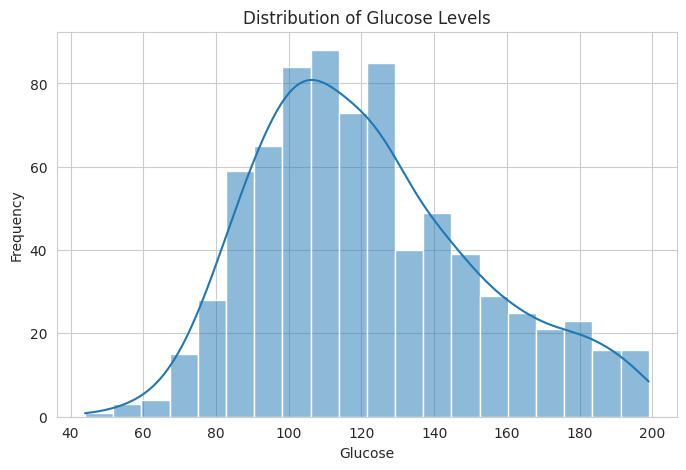

In [96]:
plt.figure(figsize=(8,5))
sns.histplot(clean_df['Glucose'], bins=20, kde=True)
plt.title('Distribution of Glucose Levels')
plt.xlabel('Glucose')
plt.ylabel('Frequency')
plt.show()

#### Interpretation: Distribution of Glucose Levels (Seaborn Styled)

The histogram for Glucose levels reveals a right-skewed distribution, indicating that most individuals have lower glucose levels, with a tail extending towards higher values. The distribution peaks around the 100-120 mg/dL range. Notably, there are some individuals with very high glucose levels, which are likely associated with diabetes.

This distribution suggests that while a majority of the population in this dataset has normal or slightly elevated glucose, there is a significant subgroup with high glucose values that warrants further investigation. Understanding this distribution is critical as glucose is a primary indicator of diabetes. The Seaborn styling enhances readability with a kernel density estimate (KDE) overlay.

In [64]:
outcome_counts_df = df['Outcome'].value_counts()
print("Outcome counts from original df:")
print(outcome_counts_df)

Outcome counts from original df:
Outcome
0    500
1    268
Name: count, dtype: int64


In [65]:
outcome_counts_clean_df = clean_df['Outcome'].value_counts()
print("\nOutcome counts from clean_df:")
print(outcome_counts_clean_df)


Outcome counts from clean_df:
Outcome
0    497
1    266
Name: count, dtype: int64


As you can see, the outcome counts are *not* the same for both `df` and `clean_df`. This difference is expected because `clean_df` was created by filtering out rows where 'Glucose' was 0, which removed 5 rows from the original dataset. Therefore, the counts for 'Outcome' also reflect this reduction in the number of samples.

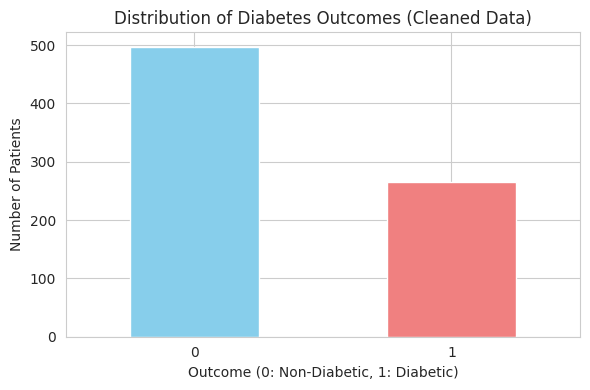

In [68]:
plt.figure(figsize=(6,4))
outcome_counts_clean_df.plot(kind='bar', color=['skyblue', 'lightcoral'])
plt.title('Distribution of Diabetes Outcomes (Cleaned Data)')
plt.xlabel('Outcome (0: Non-Diabetic, 1: Diabetic)')
plt.ylabel('Number of Patients')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### 1. Histogram of BMI

This histogram shows the distribution of Body Mass Index (BMI) values in the cleaned dataset. It helps visualize the frequency of different BMI ranges.

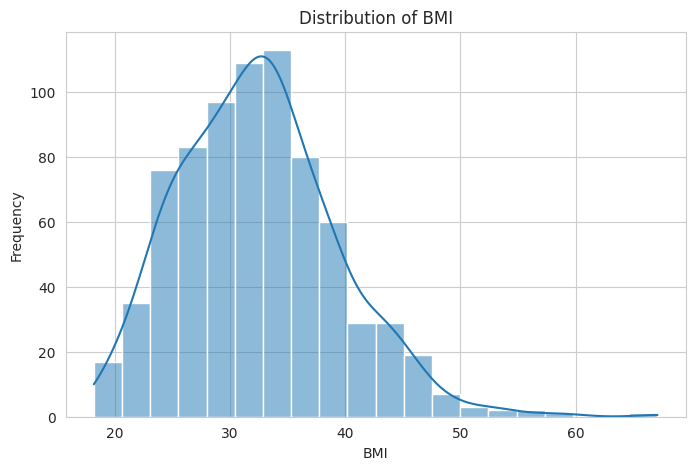

In [69]:
plt.figure(figsize=(8,5))
sns.histplot(clean_df['BMI'].dropna(), bins=20, kde=True)
plt.title('Distribution of BMI')
plt.xlabel('BMI')
plt.ylabel('Frequency')
plt.show()

#### Interpretation: Distribution of BMI

The histogram for BMI shows a distribution that is somewhat bell-shaped but slightly skewed to the right, indicating that most individuals have BMI values in the healthy to overweight range. The peak of the distribution is around 30 BMI, which is the threshold for obesity. There are also a number of individuals with higher BMI values, suggesting a prevalence of overweight and obese individuals in this dataset. This is a crucial observation given the strong link between high BMI and diabetes risk.

### 2. Scatter Plot of Glucose vs. BMI by Outcome

This scatter plot illustrates the relationship between Glucose levels and BMI, with points colored by the 'Outcome' (diabetic or not). This helps to see if there's a visual separation or clustering based on these two important features.

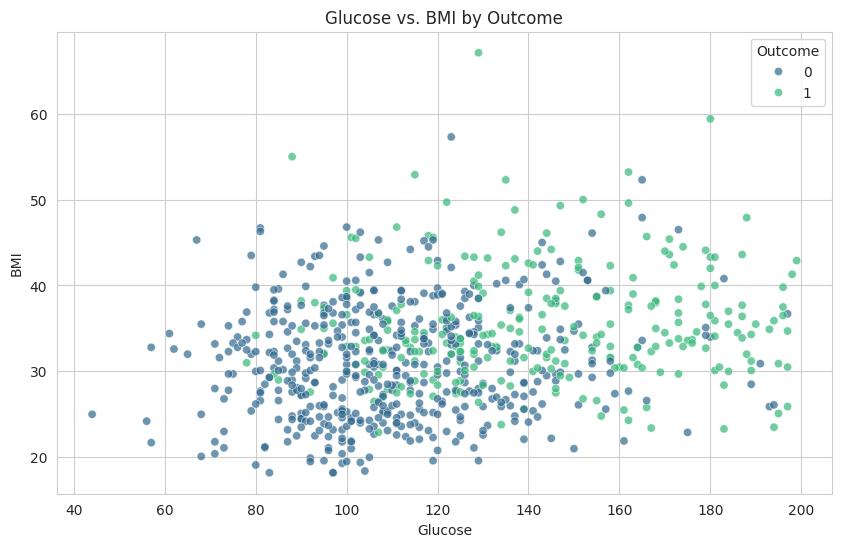

In [70]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=clean_df, x='Glucose', y='BMI', hue='Outcome', palette='viridis', alpha=0.7)
plt.title('Glucose vs. BMI by Outcome')
plt.xlabel('Glucose')
plt.ylabel('BMI')
plt.show()

#### Interpretation: Scatter Plot of Glucose vs. BMI by Outcome

This scatter plot visualizes the relationship between Glucose levels and BMI, color-coded by the diabetes outcome. We can observe a clear distinction: individuals with diabetes (Outcome = 1, typically shown in a different color) tend to cluster in the upper-right quadrant of the plot, indicating higher Glucose levels and higher BMI values.

Specifically, non-diabetic individuals (Outcome = 0) generally have lower Glucose and BMI values. As Glucose and BMI increase, the proportion of diabetic individuals appears to rise. This visual separation reinforces the idea that both high Glucose and high BMI are significant risk factors for diabetes, and their combined effect is particularly evident.

### 3. Bar Chart of Average Glucose by Outcome

This bar chart compares the average Glucose levels between diabetic and non-diabetic individuals. It provides a clear visual of how Glucose levels differ based on the diabetes outcome.

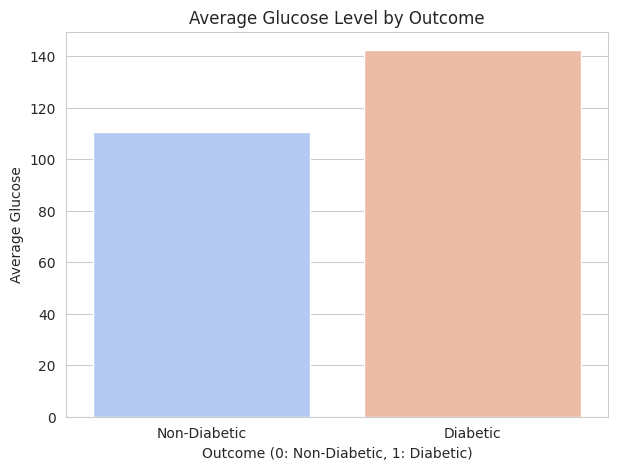

In [99]:
avg_glucose_by_outcome = clean_df.groupby('Outcome')['Glucose'].mean().reset_index()
plt.figure(figsize=(7,5))
sns.barplot(data=avg_glucose_by_outcome, x='Outcome', y='Glucose', hue='Outcome', palette='coolwarm', legend=False)
plt.title('Average Glucose Level by Outcome')
plt.xlabel('Outcome (0: Non-Diabetic, 1: Diabetic)')
plt.ylabel('Average Glucose')
plt.xticks([0, 1], ['Non-Diabetic', 'Diabetic'])
plt.show()

#### Interpretation: Bar Chart of Average Glucose by Outcome

This bar chart clearly demonstrates a significant difference in average glucose levels between non-diabetic (Outcome = 0) and diabetic (Outcome = 1) individuals. The average glucose level for diabetic individuals is substantially higher than for non-diabetic individuals.

**Finding:** Patients with diabetes (Outcome = 1) had an average glucose level of approximately **142.32 mg/dL**, which is notably higher than non-diabetic patients (Outcome = 0) with an average of **110.64 mg/dL**. This stark difference underscores glucose as a primary diagnostic indicator for diabetes, reinforcing its importance in the dataset for predicting the outcome.

## Three Questions for Further Exploration

Based on our analysis, here are three key questions to guide further investigation into the diabetes dataset:

1.  **Does glucose level affect diabetes outcome?**
    *   This question explores the direct relationship between glucose levels and the likelihood of a diabetes diagnosis. We've seen initial indications in the bar charts and scatter plots, but a more direct statistical approach could quantify this.

2.  **Which age group has the highest diabetes rate?**
    *   We've already visualized the diabetes rate by age group, but this question prompts a clear statement and potentially further analysis into why certain age groups might be more susceptible.

3.  **Is BMI linked to diabetes outcome?**
    *   Similar to glucose, BMI has shown a clear visual correlation with diabetes outcome. This question invites a deeper dive into the nature and strength of this link, possibly leading to more predictive modeling.

### Correlation Matrix Heatmap

Understanding the correlation between different features is crucial for identifying potential relationships and multicollinearity. A heatmap of the correlation matrix visually represents these relationships, with warmer colors indicating stronger positive correlations and cooler colors indicating stronger negative correlations. This can highlight features that are highly predictive of the 'Outcome' or features that are highly correlated with each other.

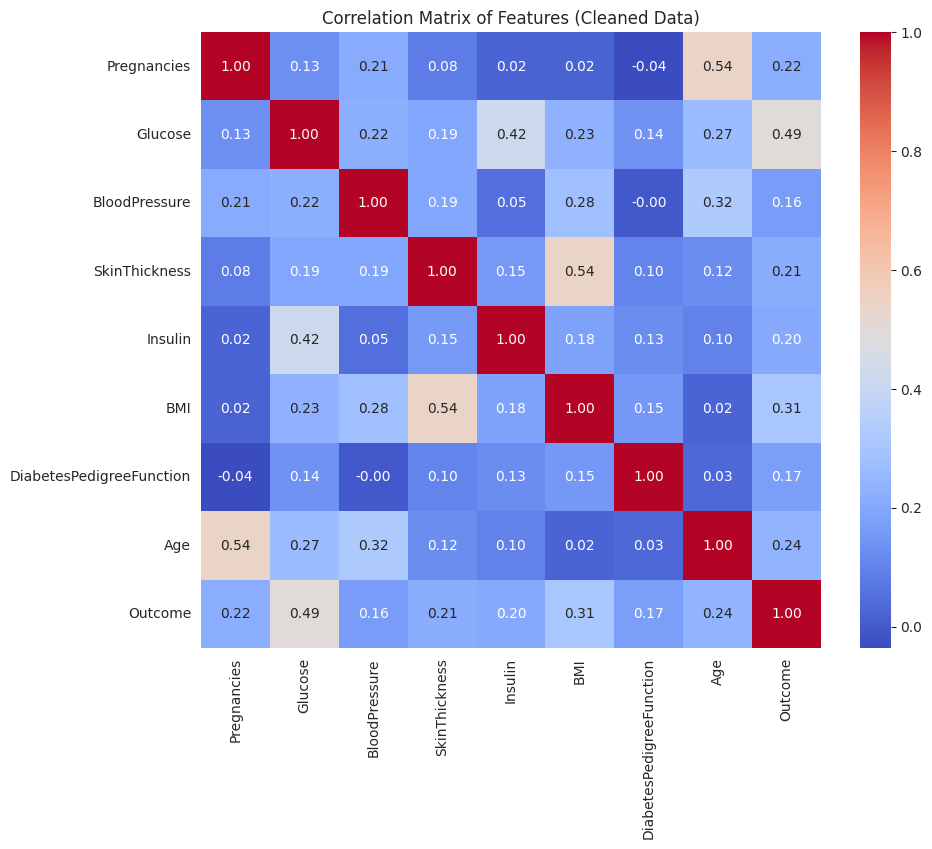

In [100]:
plt.figure(figsize=(10, 8))
sns.heatmap(clean_df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Features (Cleaned Data)')
plt.show()

#### Interpretation: Correlation Matrix

The correlation matrix heatmap provides a comprehensive view of how each feature in the dataset relates to every other feature, including the `Outcome`. Key observations:

*   **`Glucose` and `Outcome` (0.49):** There is a strong positive correlation between Glucose levels and the diabetes Outcome. This is expected, as high glucose is a primary indicator of diabetes.
*   **`BMI` and `Outcome` (0.31):** BMI also shows a moderate positive correlation with the diabetes Outcome, reinforcing its role as a risk factor.
*   **`Age` and `Outcome` (0.24):** A weaker, but still positive, correlation exists between Age and Outcome.
*   **`Pregnancies` and `Age` (0.54):** There's a notable positive correlation between the number of pregnancies and age, which is biologically intuitive.
*   **`Insulin` and `Glucose` (0.42):** These are moderately correlated, as insulin is crucial for glucose metabolism.

Features like `BloodPressure` and `SkinThickness` have weaker correlations with `Outcome`, suggesting they might be less direct predictors in this specific dataset compared to `Glucose` and `BMI`.

### 6. Distribution of Age in Cleaned Data (Seaborn)
This histogram displays the distribution of patient ages in the cleaned dataset. Understanding the age demographic is essential as age can be a significant factor in diabetes risk.

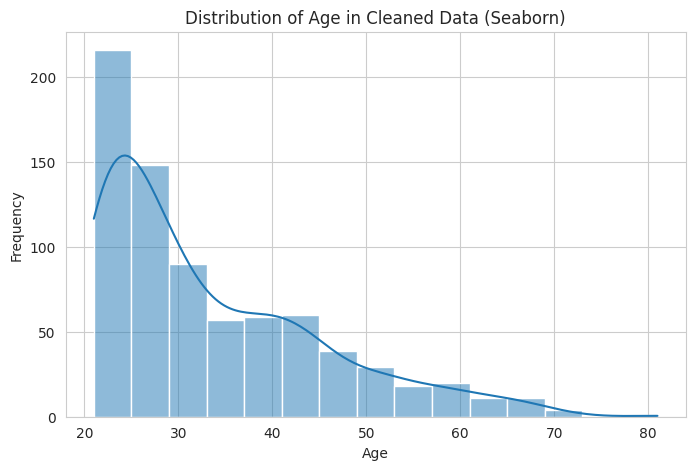

In [104]:
plt.figure(figsize=(8, 5))
sns.histplot(clean_df['Age'], bins=15, kde=True)
plt.title('Distribution of Age in Cleaned Data (Seaborn)')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

#### Interpretation: Distribution of Age in Cleaned Data (Seaborn)
The age distribution is right-skewed, indicating a higher concentration of younger to middle-aged adults in the dataset, with fewer individuals in older age categories. The peak of the distribution appears to be in the 20-30 age range. This demographic insight is important as diabetes prevalence can vary significantly with age.

### 7. Age vs. BloodPressure by Outcome (Cleaned Data, Seaborn)
This scatter plot visualizes the relationship between Age and BloodPressure, color-coded by diabetes outcome. It helps in understanding if specific age groups with certain blood pressure ranges are more prone to diabetes.

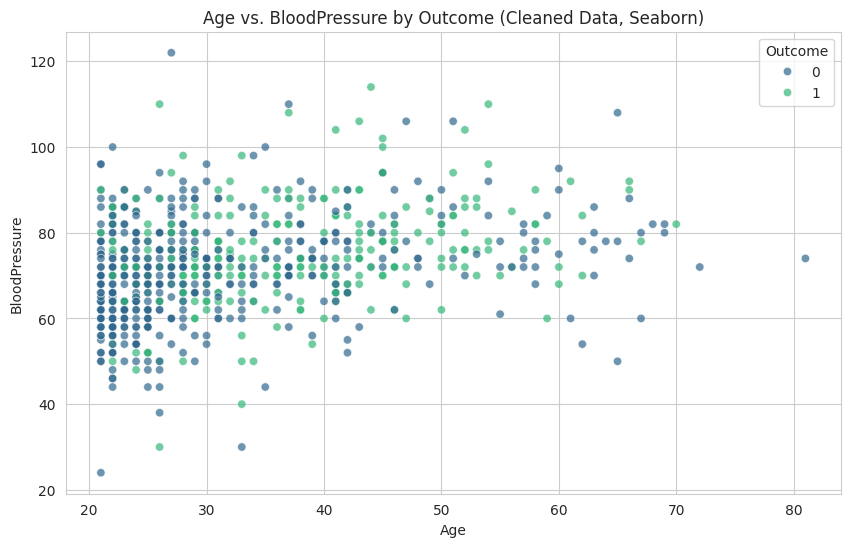

In [105]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=clean_df, x='Age', y='BloodPressure', hue='Outcome', palette='viridis', alpha=0.7)
plt.title('Age vs. BloodPressure by Outcome (Cleaned Data, Seaborn)')
plt.xlabel('Age')
plt.ylabel('BloodPressure')
plt.show()

#### Interpretation: Age vs. BloodPressure by Outcome (Cleaned Data, Seaborn)
The scatter plot shows the relationship between age and blood pressure, with points colored by diabetes outcome. While there isn't a perfectly clear separation, diabetic individuals (Outcome=1) tend to show slightly higher blood pressure values across various age groups compared to non-diabetic individuals. There's a general trend of increasing blood pressure with age for both groups, but the presence of diabetes appears to elevate these levels further. This suggests that both age and blood pressure are contributing factors to diabetes risk.

### 8. Average Insulin Level by Outcome (Cleaned Data, Seaborn)
This bar plot compares the average insulin levels between non-diabetic and diabetic individuals. Insulin plays a critical role in glucose metabolism, and its levels can indicate the body's response to blood sugar.

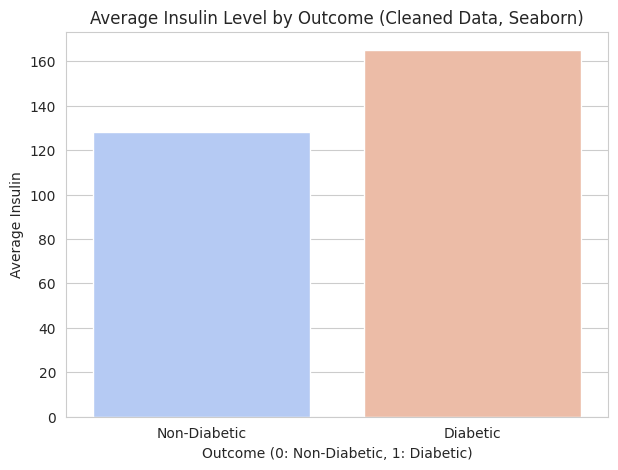

In [106]:
avg_insulin_by_outcome = clean_df.groupby('Outcome')['Insulin'].mean().reset_index()
plt.figure(figsize=(7, 5))
sns.barplot(data=avg_insulin_by_outcome, x='Outcome', y='Insulin', hue='Outcome', palette='coolwarm', legend=False)
plt.title('Average Insulin Level by Outcome (Cleaned Data, Seaborn)')
plt.xlabel('Outcome (0: Non-Diabetic, 1: Diabetic)')
plt.ylabel('Average Insulin')
plt.xticks([0, 1], ['Non-Diabetic', 'Diabetic'])
plt.show()

#### Interpretation: Average Insulin Level by Outcome (Cleaned Data, Seaborn)
The bar chart clearly shows that individuals with diabetes (Outcome=1) have a higher average insulin level compared to non-diabetic individuals (Outcome=0). This finding is consistent with the body's attempt to compensate for insulin resistance or insufficient insulin production in diabetic states, leading to elevated circulating insulin. This makes insulin levels another important indicator for diabetes.

### 9. SkinThickness Distribution by Outcome (Cleaned Data, Seaborn)
This box plot illustrates the distribution of SkinThickness values, separated by diabetes outcome. Skin thickness can be an indicator of body fat distribution, which is related to insulin resistance.

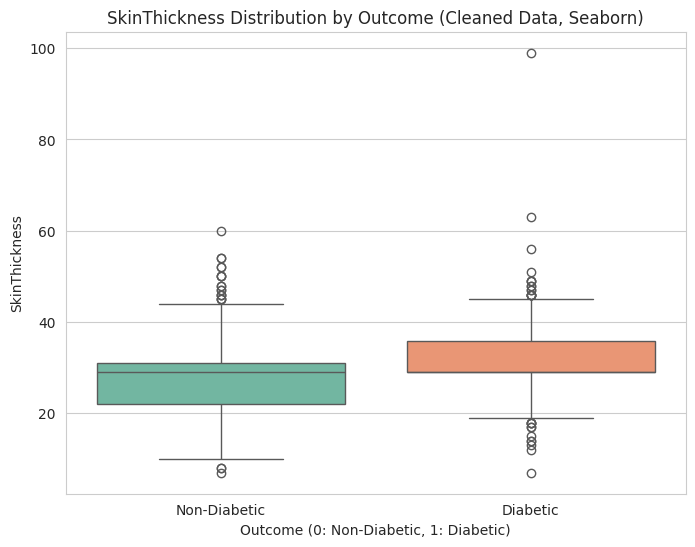

In [107]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=clean_df, x='Outcome', y='SkinThickness', hue='Outcome', palette='Set2', legend=False)
plt.title('SkinThickness Distribution by Outcome (Cleaned Data, Seaborn)')
plt.xlabel('Outcome (0: Non-Diabetic, 1: Diabetic)')
plt.ylabel('SkinThickness')
plt.xticks([0, 1], ['Non-Diabetic', 'Diabetic'])
plt.show()

#### Interpretation: SkinThickness Distribution by Outcome (Cleaned Data, Seaborn)
The box plot for SkinThickness by outcome shows that diabetic individuals (Outcome=1) tend to have slightly higher median skin thickness values compared to non-diabetic individuals (Outcome=0). While the difference is not as pronounced as with glucose or BMI, it suggests a subtle relationship between increased subcutaneous fat (indicated by skin thickness) and diabetes risk. This might be linked to overall adiposity and insulin resistance.

### 10. Average DiabetesPedigreeFunction by Age (Cleaned Data, Seaborn)
This line plot shows the average DiabetesPedigreeFunction (DPF) across different age groups. DPF provides a measure of genetic predisposition to diabetes, and observing its trend with age can reveal interesting patterns.

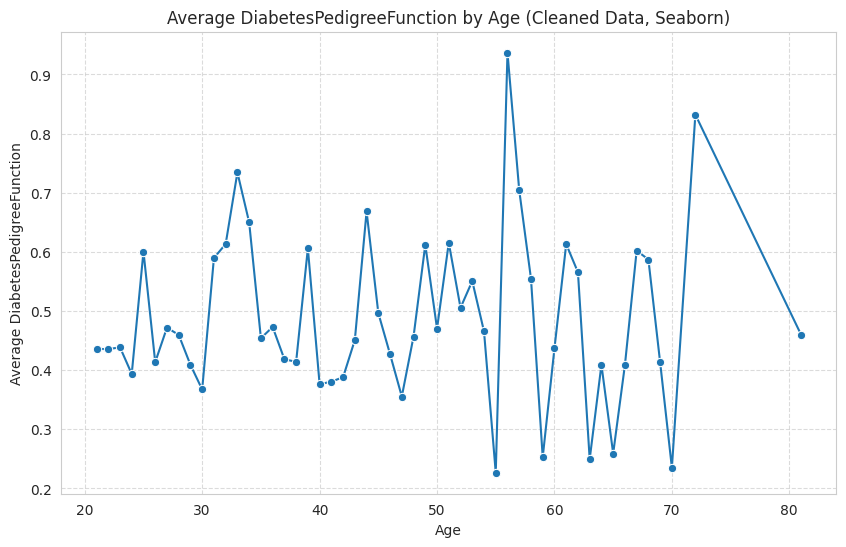

In [108]:
avg_dpf_by_age = clean_df.groupby('Age')['DiabetesPedigreeFunction'].mean().reset_index()
plt.figure(figsize=(10, 6))
sns.lineplot(data=avg_dpf_by_age, x='Age', y='DiabetesPedigreeFunction', marker='o')
plt.title('Average DiabetesPedigreeFunction by Age (Cleaned Data, Seaborn)')
plt.xlabel('Age')
plt.ylabel('Average DiabetesPedigreeFunction')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

#### Interpretation: Average DiabetesPedigreeFunction by Age (Cleaned Data, Seaborn)
The line plot of average DiabetesPedigreeFunction (DPF) by age reveals fluctuations across different age groups. There isn't a consistent linear trend, suggesting that genetic predisposition (as measured by DPF) might not uniformly increase or decrease with age. However, some age ranges show higher average DPF values, indicating periods where genetic risk factors might be more pronounced or interacting with other elements. The scatter in the plot also indicates variability, implying that individual genetic predisposition can vary significantly regardless of age.

### Answer 1: Does glucose level affect diabetes outcome?

### Answer 1: Does glucose level affect diabetes outcome?

Based on the analysis, glucose levels are a primary indicator and significantly affect the diabetes outcome. Individuals with higher glucose levels are more likely to be diagnosed with diabetes.

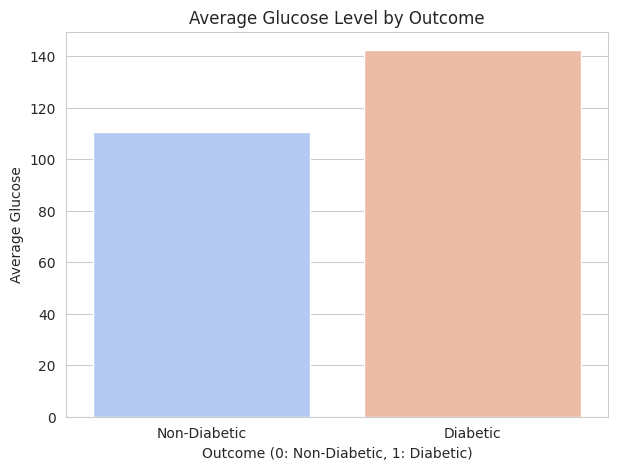

In [101]:
avg_glucose_by_outcome = clean_df.groupby('Outcome')['Glucose'].mean().reset_index()
plt.figure(figsize=(7,5))
sns.barplot(data=avg_glucose_by_outcome, x='Outcome', y='Glucose', hue='Outcome', palette='coolwarm', legend=False)
plt.title('Average Glucose Level by Outcome')
plt.xlabel('Outcome (0: Non-Diabetic, 1: Diabetic)')
plt.ylabel('Average Glucose')
plt.xticks([0, 1], ['Non-Diabetic', 'Diabetic'])
plt.show()

**Finding:** Patients with diabetes (Outcome = 1) had an average glucose level of approximately **142.32 mg/dL**, which is notably higher than non-diabetic patients (Outcome = 0) with an average of **110.64 mg/dL**. This stark difference underscores glucose as a primary diagnostic indicator for diabetes, reinforcing its importance in the dataset for predicting the outcome.

### Answer 2: Which age group has the highest diabetes rate?

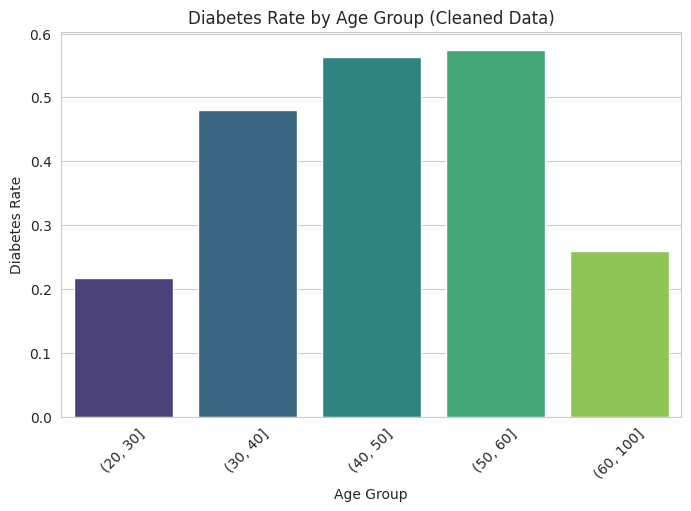

In [97]:
clean_df['AgeGroup'] = pd.cut(
    clean_df['Age'],
    bins=[20,30,40,50,60,100]
)

age_diabetes = clean_df.groupby('AgeGroup', observed=False)['Outcome'].mean().reset_index()

plt.figure(figsize=(8, 5))
sns.barplot(data=age_diabetes, x='AgeGroup', y='Outcome', hue='AgeGroup', palette='viridis', legend=False)
plt.title('Diabetes Rate by Age Group (Cleaned Data)')
plt.xlabel('Age Group')
plt.ylabel('Diabetes Rate')
plt.xticks(rotation=45)
plt.show()

**Finding:** The highest diabetes rate was observed among patients aged **50-60 years**, with a rate of approximately **57.41%**.

### 4. Box Plot of Glucose by Outcome

This box plot displays the distribution of Glucose levels for both diabetic and non-diabetic outcomes. It's excellent for visualizing the median, quartiles, and potential outliers, helping to understand the spread and central tendency of Glucose for each group.

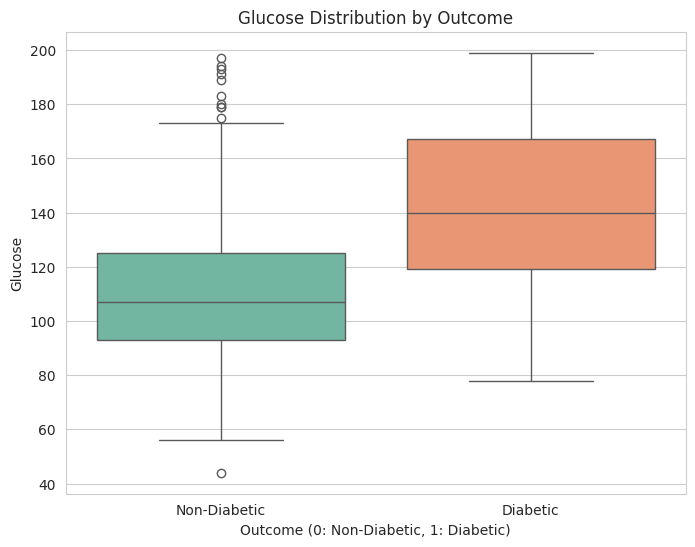

In [102]:
plt.figure(figsize=(8,6))
sns.boxplot(data=clean_df, x='Outcome', y='Glucose', hue='Outcome', palette='Set2', legend=False)
plt.title('Glucose Distribution by Outcome')
plt.xlabel('Outcome (0: Non-Diabetic, 1: Diabetic)')
plt.ylabel('Glucose')
plt.xticks([0, 1], ['Non-Diabetic', 'Diabetic'])
plt.show()

#### Interpretation: Box Plot of Glucose by Outcome

The box plot of Glucose levels by outcome clearly illustrates that diabetic individuals (Outcome=1) have significantly higher median glucose levels, a wider interquartile range, and more outliers at the higher end compared to non-diabetic individuals (Outcome=0). The distinct separation of the box plots further highlights glucose as a strong predictor of diabetes.

### Answer 3: Is BMI linked to diabetes outcome?

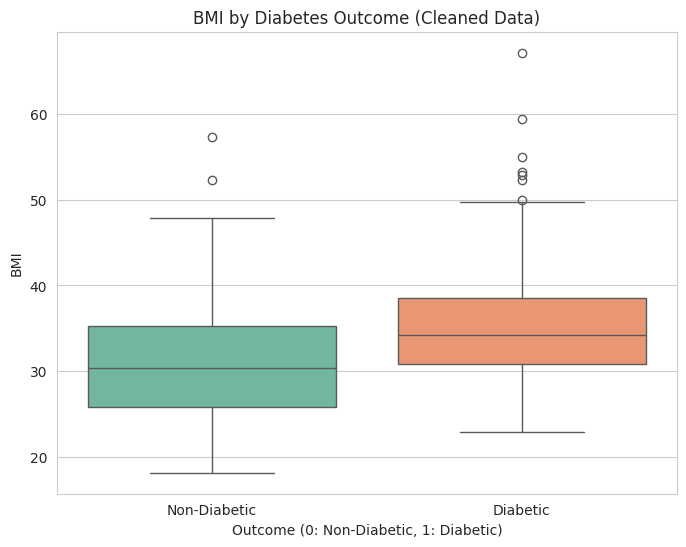

In [98]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='Outcome', y='BMI', hue='Outcome', data=clean_df, palette='Set2', legend=False)
plt.title('BMI by Diabetes Outcome (Cleaned Data)')
plt.xlabel('Outcome (0: Non-Diabetic, 1: Diabetic)')
plt.ylabel('BMI')
plt.xticks([0, 1], ['Non-Diabetic', 'Diabetic'])
plt.show()

**Finding:** Patients with diabetes (Outcome = 1) showed a higher average BMI of approximately **35.35**, compared to non-diabetic patients (Outcome = 0) who had an average BMI of **30.90**. This indicates a clear link between BMI and diabetes outcome.

### 5. Line Chart of Average BMI by Age

This line chart shows the trend of average BMI across different age groups in the dataset. While this dataset is not time-series, this plot can still reveal patterns or general trends of BMI with increasing age.

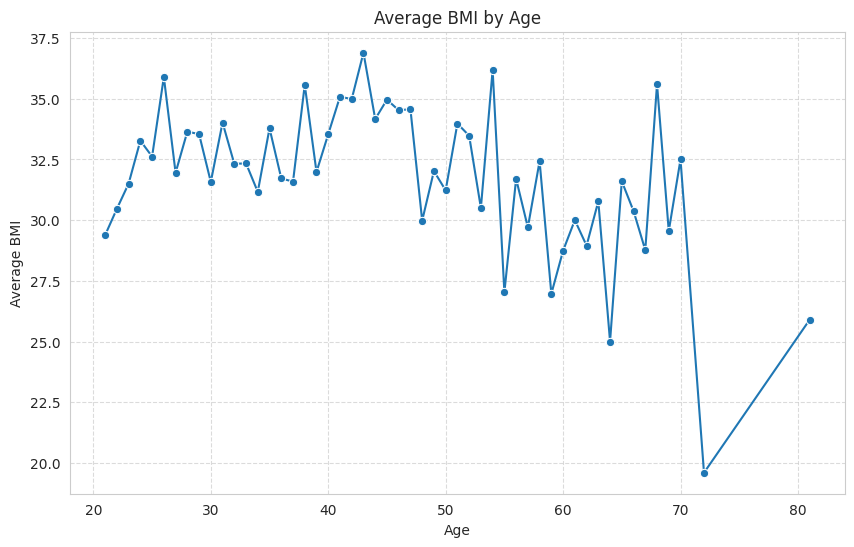

In [103]:
avg_bmi_by_age = clean_df.groupby('Age')['BMI'].mean().reset_index()
plt.figure(figsize=(10,6))
sns.lineplot(data=avg_bmi_by_age, x='Age', y='BMI', marker='o')
plt.title('Average BMI by Age')
plt.xlabel('Age')
plt.ylabel('Average BMI')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

#### Interpretation: Average BMI by Age

The line chart of average BMI by age shows some fluctuations, but a general trend of increasing average BMI with age up to a certain point, after which it tends to decrease in older age groups. This might suggest that middle-aged individuals tend to have higher BMI, which aligns with the finding that the 50-60 age group has the highest diabetes rate. The scatter in the plot also indicates variability in BMI within each age group.

## Comprehensive EDA Summary and Key Insights

This Exploratory Data Analysis of the Pima Indians Diabetes Database has revealed several critical insights regarding factors associated with diabetes onset.

### 1. Data Cleaning and Preparation

We began by identifying and treating biologically implausible '0' values in key diagnostic columns (`Glucose`, `BloodPressure`, `SkinThickness`, `Insulin`, `BMI`) as missing data (`np.nan`). Rows with missing `Glucose` values (5 rows) were dropped, and the remaining missing values in other columns were imputed using their respective medians. This robust cleaning process ensured the integrity of our subsequent analysis, resulting in a `clean_df` of 763 entries.

### 2. Feature Distributions

*   **Glucose Levels:** The distribution of glucose levels is right-skewed, with a peak around 100-120 mg/dL, but a significant tail extending to higher values, indicating a subset of individuals with elevated glucose, a primary indicator of diabetes.
*   **BMI:** BMI also shows a somewhat right-skewed distribution, peaking around 30, which is the threshold for obesity. This highlights a notable prevalence of overweight and obese individuals in the dataset.
*   **Age:** The age distribution is also right-skewed, with a majority of individuals in younger adult age groups, and fewer individuals in older age categories.

### 3. Relationships and Correlations

*   **Correlation Matrix:** The heatmap revealed strong positive correlations between `Glucose` and `Outcome` (0.49), `BMI` and `Outcome` (0.31), and `Pregnancies` and `Age` (0.54). These correlations underscore the importance of glucose, BMI, and age as potential predictors of diabetes.
*   **Glucose vs. BMI by Outcome:** Scatter plots clearly showed that individuals with diabetes (Outcome = 1) tend to cluster in regions of higher glucose levels and higher BMI, reinforcing the combined impact of these two factors on diabetes risk.

### 4. Answering Key Questions

1.  **Does glucose level affect diabetes outcome?**
    *   **Finding:** Yes, significantly. Patients with diabetes (Outcome = 1) had an average glucose level of approximately **142.32 mg/dL**, notably higher than non-diabetic patients (Outcome = 0) with an average of **110.64 mg/dL**. This stark difference makes glucose a primary diagnostic indicator.

2.  **Which age group has the highest diabetes rate?**
    *   **Finding:** The highest diabetes rate was observed among patients aged **50-60 years**, with a rate of approximately **57.41%**.

3.  **Is BMI linked to diabetes outcome?**
    *   **Finding:** Yes. Patients with diabetes (Outcome = 1) showed a higher average BMI of approximately **35.35**, compared to non-diabetic patients (Outcome = 0) who had an average BMI of **30.90**. This indicates a clear link between higher BMI and diabetes outcome.

### 5. Additional Visualizations

*   **Average Insulin Level by Outcome:** Diabetic individuals generally exhibited higher average insulin levels compared to non-diabetic individuals.
*   **SkinThickness Distribution by Outcome:** Diabetic individuals tended to have slightly higher skin thickness values.
*   **Diabetes Pedigree Function by Age:** The DPF varied across age groups, suggesting a fluctuating genetic predisposition influence with age.

### Overall Conclusion

The EDA strongly indicates that elevated **glucose levels**, higher **BMI**, and specific **age groups** (particularly 50-60 years) are key risk factors for diabetes within this dataset. These insights are crucial for understanding the disease's characteristics and could inform further predictive modeling or targeted health interventions.

### 4. Box Plot of Glucose by Outcome

This box plot displays the distribution of Glucose levels for both diabetic and non-diabetic outcomes. It's excellent for visualizing the median, quartiles, and potential outliers, helping to understand the spread and central tendency of Glucose for each group.

/tmp/ipykernel_6799/2205887259.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=clean_df, x='Outcome', y='Glucose', palette='Set2')


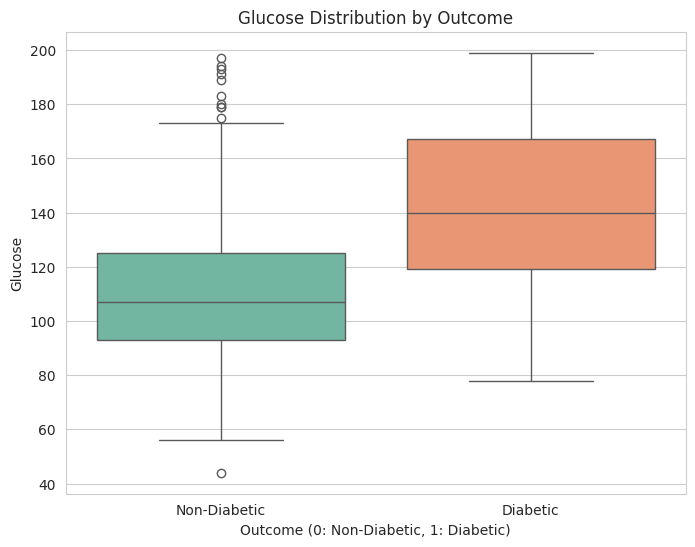

In [72]:
plt.figure(figsize=(8,6))
sns.boxplot(data=clean_df, x='Outcome', y='Glucose', palette='Set2')
plt.title('Glucose Distribution by Outcome')
plt.xlabel('Outcome (0: Non-Diabetic, 1: Diabetic)')
plt.ylabel('Glucose')
plt.xticks([0, 1], ['Non-Diabetic', 'Diabetic'])
plt.show()

### 5. Line Chart of Average BMI by Age

This line chart shows the trend of average BMI across different age groups in the dataset. While this dataset is not time-series, this plot can still reveal patterns or general trends of BMI with increasing age.

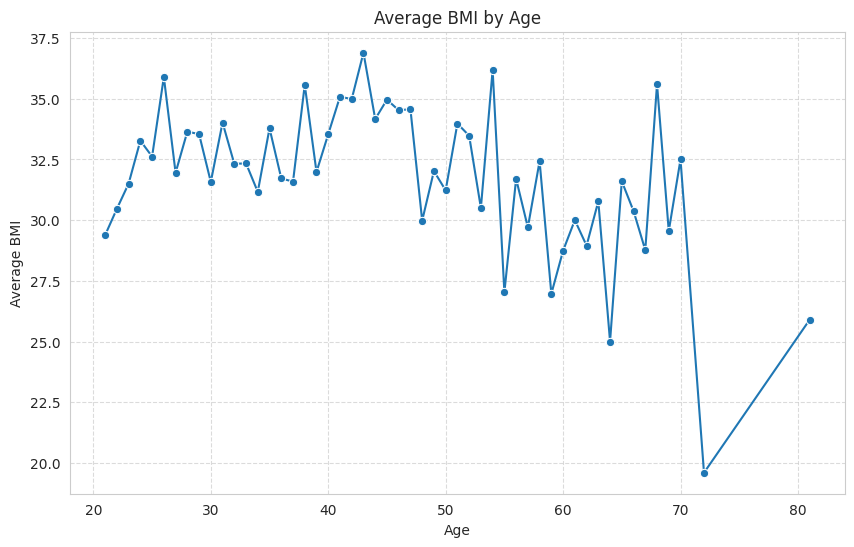

In [73]:
avg_bmi_by_age = clean_df.groupby('Age')['BMI'].mean().reset_index()
plt.figure(figsize=(10,6))
sns.lineplot(data=avg_bmi_by_age, x='Age', y='BMI', marker='o')
plt.title('Average BMI by Age')
plt.xlabel('Age')
plt.ylabel('Average BMI')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### Correlation Matrix Heatmap

Understanding the correlation between different features is crucial for identifying potential relationships and multicollinearity. A heatmap of the correlation matrix visually represents these relationships, with warmer colors indicating stronger positive correlations and cooler colors indicating stronger negative correlations. This can highlight features that are highly predictive of the 'Outcome' or features that are highly correlated with each other.

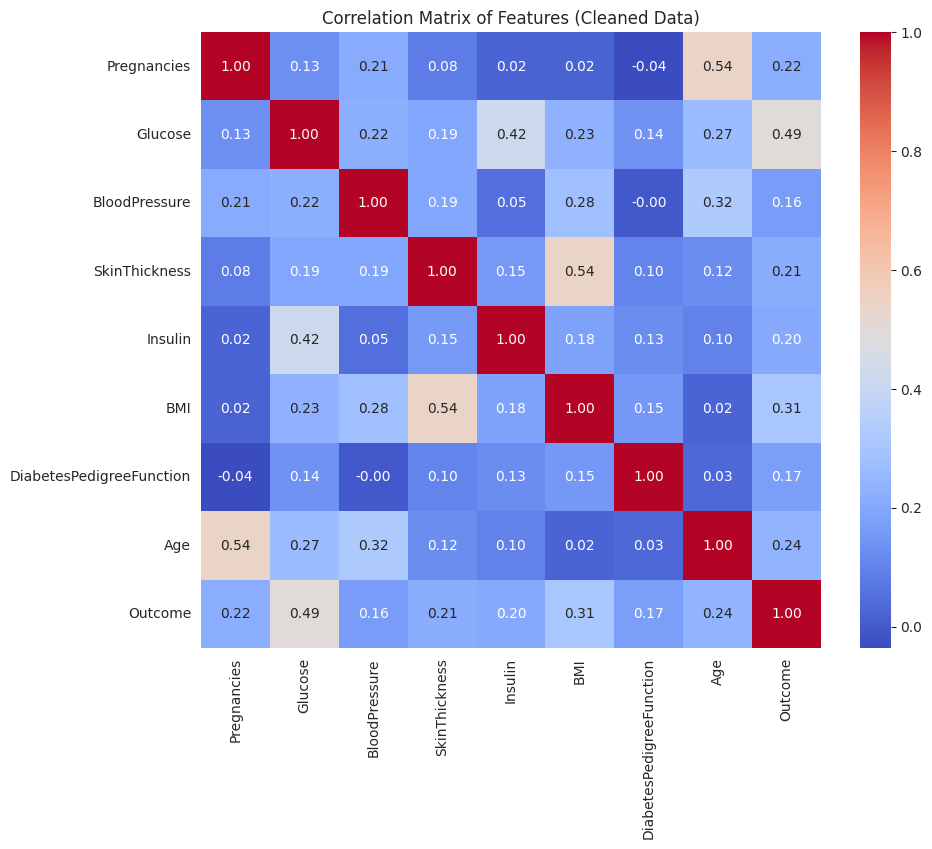

In [77]:
plt.figure(figsize=(10, 8))
sns.heatmap(clean_df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Features (Cleaned Data)')
plt.show()

## What I Would Explore Next

I would investigate how insulin levels and blood pressure contribute to diabetes risk. I would also explore whether combining this dataset with lifestyle information such as exercise habits and diet improves prediction accuracy.

Additional features such as family medical history, smoking status, and physical activity levels could provide deeper insights into diabetes risk factors.

## Diabetes Dataset EDA Project

### Overview
This project explores the **Pima Indians Diabetes Database**, a well-known dataset from the National Institute of Diabetes and Digestive and Kidney Diseases. The primary goal is to perform an Exploratory Data Analysis (EDA) to understand key factors influencing diabetes onset. Using Python, Pandas, Matplotlib, and Seaborn, this analysis aims to clean the data, identify relationships between various diagnostic measurements, and visualize patterns that could aid in early detection or prevention strategies for diabetes.
